In [2]:
import pandas as pd

train_data = pd.read_csv('csv/train_dataset.csv')
test_data = pd.read_csv('csv/test_dataset.csv')
validation_data = pd.read_csv('csv/val_dataset.csv')

In [3]:
!pip install seaborn

Train Data Description:
                   ID                                               Text  \
count   148388.000000                                             148388   
unique            NaN                                             148388   
top               NaN  http://twitpic.com/7mwrd - Arby's took down th...   
freq              NaN                                                  1   
mean    106024.578699                                                NaN   
std      61150.300085                                                NaN   
min          0.000000                                                NaN   
25%      53237.500000                                                NaN   
50%     105998.000000                                                NaN   
75%     158927.250000                                                NaN   
max     211981.000000                                                NaN   

                Label  
count   148388.000000  
unique         

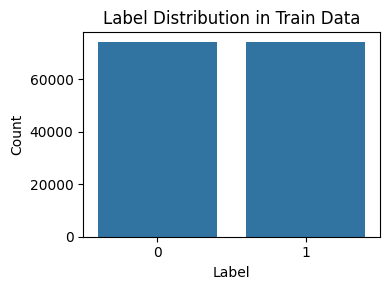

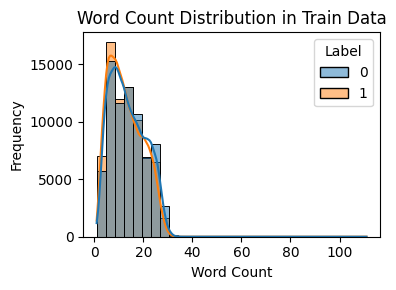

In [4]:
import seaborn as sns

import matplotlib.pyplot as plt

# Descriptive statistics for train_data
print("Train Data Description:")
print(train_data.describe(include='all'))

# Check for missing values in train_data
print("\nMissing Values in Train Data:")
print(train_data.isnull().sum())

# Distribution of the Label column in train_data
label_counts = train_data['Label'].value_counts()
print("\nLabel Distribution in Train Data:")
print(label_counts)

# Visualization of Label distribution
plt.figure(figsize=(4, 3))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Label Distribution in Train Data')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plots/label_distribution.png', dpi=300)
plt.show()

# Word count distribution in the Text column
train_data['word_count'] = train_data['Text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(4, 3))
sns.histplot(data=train_data, x='word_count', hue='Label', bins=30, kde=True, color='blue')
plt.title('Word Count Distribution in Train Data')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('plots/word_count_distribution.png', dpi=300)
plt.show()

In [5]:
import html
import re

# Function to preprocess text
def preprocess_text(text):
    # Unescape HTML characters
    text = html.unescape(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing to train, test, and validation datasets
train_data['Clean'] = train_data['Text'].apply(preprocess_text)
test_data['Clean'] = test_data['Text'].apply(preprocess_text)
validation_data['Clean'] = validation_data['Text'].apply(preprocess_text)

# Display a sample of the cleaned text
print(train_data[['Text', 'Clean']].head())

                                                Text  \
0      @whoisralphie dude  I'm so bummed ur leaving!   
1  oh my god, a severed foot was foun in a wheely...   
2  I end up &quot;dog dialing&quot; sumtimes. Wha...   
3                         @_rachelx meeeee toooooo!    
4  I was hoping I could stay home and work today,...   

                                               Clean  
0          whoisralphie dude im so bummed ur leaving  
1  oh my god a severed foot was foun in a wheely ...  
2  i end up dog dialing sumtimes whats dog dialin...  
3                             rachelx meeeee toooooo  
4  i was hoping i could stay home and work today ...  


In [6]:
!pip install wordcloud

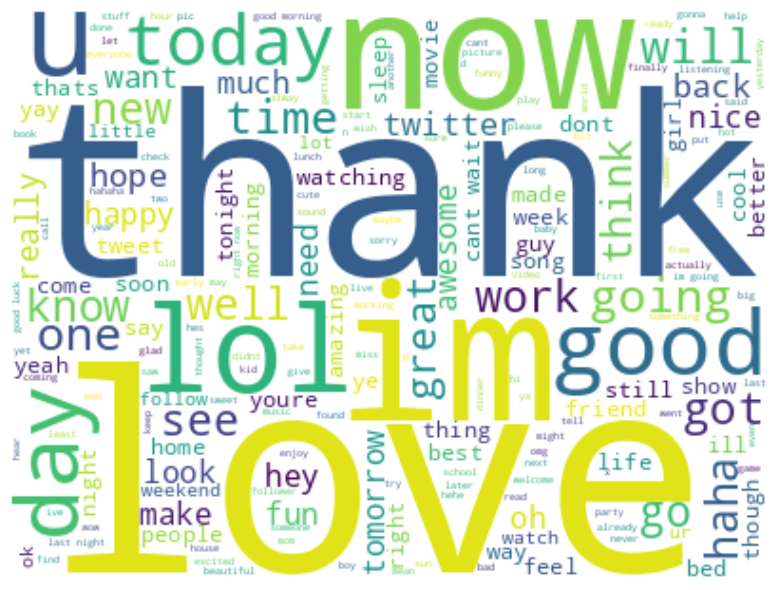

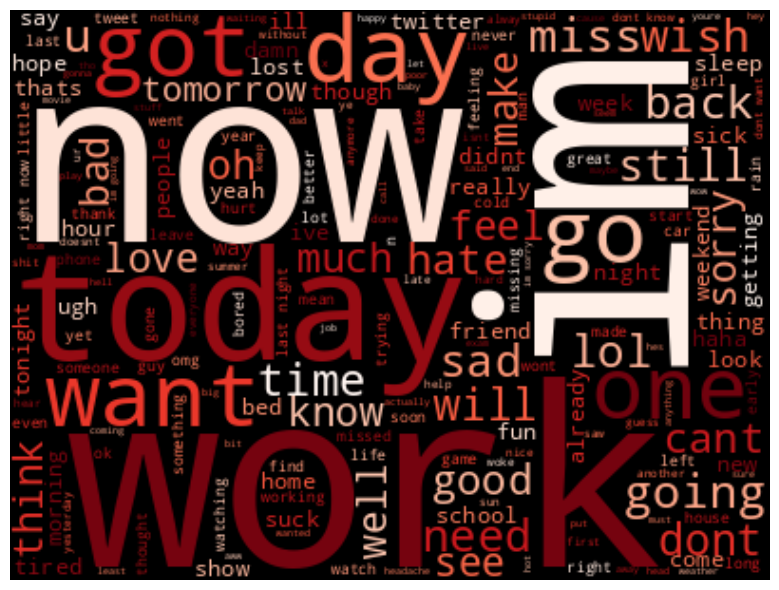

Average Word Count for Positive Tweets: 12.849695401369345
Average Word Count for Negative Tweets: 13.728649989217166


In [7]:
from wordcloud import WordCloud
from collections import Counter

# Generate word clouds for positive and negative tweets
positive_tweets = train_data[train_data['Label'] == 1]['Clean']
negative_tweets = train_data[train_data['Label'] == 0]['Clean']

# Word cloud for positive tweets
positive_wordcloud = WordCloud(width=400, height=300, background_color='white').generate(' '.join(positive_tweets))
plt.figure(figsize=(10, 6))
plt.imshow(positive_wordcloud, interpolation='bilinear')
# plt.title('Word Cloud for Positive Tweets')
plt.axis('off')
plt.tight_layout()
plt.savefig('plots/word_cloud_positive.png', dpi=300)
plt.show()

# Word cloud for negative tweets
negative_wordcloud = WordCloud(width=400, height=300, background_color='black', colormap='Reds').generate(' '.join(negative_tweets))
plt.figure(figsize=(10, 6))
plt.imshow(negative_wordcloud, interpolation='bilinear')
# plt.title('Word Cloud for Negative Tweets')
plt.axis('off')
plt.tight_layout()
plt.savefig('plots/word_cloud_negative.png', dpi=300)
plt.show()

# Average word count for positive and negative tweets
avg_word_count_positive = train_data[train_data['Label'] == 1]['word_count'].mean()
avg_word_count_negative = train_data[train_data['Label'] == 0]['word_count'].mean()
print(f"Average Word Count for Positive Tweets: {avg_word_count_positive}")
print(f"Average Word Count for Negative Tweets: {avg_word_count_negative}")


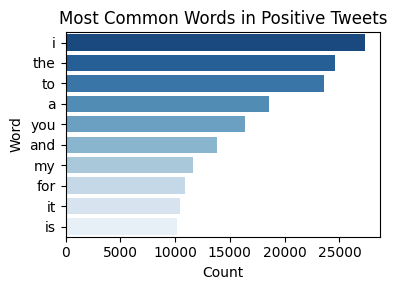

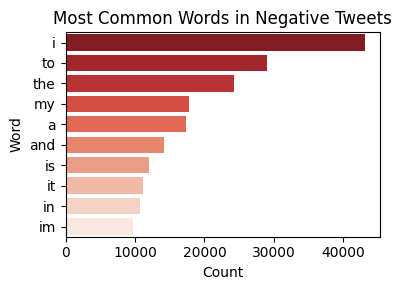

In [8]:
# Most common words in positive and negative tweets
positive_words = Counter(" ".join(positive_tweets).split()).most_common(10)
negative_words = Counter(" ".join(negative_tweets).split()).most_common(10)

# Plot most common positive words
positive_words_df = pd.DataFrame(positive_words, columns=['Word', 'Count'])
plt.figure(figsize=(4, 3))
sns.barplot(x='Count', y='Word', hue='Word', data=positive_words_df, palette='Blues_r')
plt.title('Most Common Words in Positive Tweets')
plt.xlabel('Count')
plt.ylabel('Word')
plt.tight_layout()
plt.savefig('plots/positive_words.png', dpi=300)
plt.show()

# Plot most common negative words
negative_words_df = pd.DataFrame(negative_words, columns=['Word', 'Count'])
plt.figure(figsize=(4, 3))
sns.barplot(x='Count', y='Word', hue='Word', data=negative_words_df, palette='Reds_r')
plt.title('Most Common Words in Negative Tweets')
plt.xlabel('Count')
plt.ylabel('Word')
plt.tight_layout()
plt.savefig('plots/negative_words.png', dpi=300)
plt.show()

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

# Vectorize the cleaned text in train, test, and validation datasets
X_train = tfidf_vectorizer.fit_transform(train_data['Clean'])
X_val = tfidf_vectorizer.transform(validation_data['Clean'])
X_test = tfidf_vectorizer.transform(test_data['Clean'])

y_train = train_data['Label']
y_val = validation_data['Label']

# Display the shape of the resulting matrices
print(f"Shape of X_train: {X_train.shape}, Shape of y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}, Shape of y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (148388, 133281), Shape of y_train: (148388,)
Shape of X_val: (42396, 133281), Shape of y_val: (42396,)
Shape of X_test: (21199, 133281)


In [10]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create a DummyClassifier
dummy_model = DummyClassifier(strategy="uniform")

# Fit the model on the training data
dummy_model.fit(X_train, y_train)

# Predict on the validation data
y_val_pred_dummy = dummy_model.predict(X_val)

# Evaluate the model
accuracy_dummy = accuracy_score(y_val, y_val_pred_dummy)
print(f"Dummy Model Accuracy: {accuracy_dummy:.4f}")

# Classification report
print("\nClassification Report for Dummy Model:")
print(classification_report(y_val, y_val_pred_dummy))

Dummy Model Accuracy: 0.5013

Classification Report for Dummy Model:
              precision    recall  f1-score   support

           0       0.50      0.50      0.50     21197
           1       0.50      0.50      0.50     21199

    accuracy                           0.50     42396
   macro avg       0.50      0.50      0.50     42396
weighted avg       0.50      0.50      0.50     42396



In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train a Logistic Regression model
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train, y_train)

# Predict on the validation data
y_val_pred_logistic = logistic_model.predict(X_val)

# Evaluate the model
accuracy_logistic = accuracy_score(y_val, y_val_pred_logistic)
print(f"Logistic Regression Model Accuracy: {accuracy_logistic:.4f}")

# Classification report
print("\nClassification Report for Logistic Regression Model:")
print(classification_report(y_val, y_val_pred_logistic))

Logistic Regression Model Accuracy: 0.7898

Classification Report for Logistic Regression Model:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79     21197
           1       0.79      0.79      0.79     21199

    accuracy                           0.79     42396
   macro avg       0.79      0.79      0.79     42396
weighted avg       0.79      0.79      0.79     42396



In [12]:
!pip install nltk
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [13]:
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the PorterStemmer
stemmer = PorterStemmer()

# Apply stemming to the cleaned text in the training and validation datasets
train_data['Stemmed'] = train_data['Clean'].apply(lambda x: ' '.join([stemmer.stem(word) for word in x.split()]))
validation_data['Stemmed'] = validation_data['Clean'].apply(lambda x: ' '.join([stemmer.stem(word) for word in x.split()]))

# Initialize a new TF-IDF vectorizer for the stemmed text
tfidf_vectorizer_stemmed = TfidfVectorizer()

# Vectorize the stemmed text
X_train_stemmed = tfidf_vectorizer_stemmed.fit_transform(train_data['Stemmed'])
X_val_stemmed = tfidf_vectorizer_stemmed.transform(validation_data['Stemmed'])

# Train a new logistic regression model on the stemmed training data
logistic_model_stemmed = LogisticRegression(random_state=42)
logistic_model_stemmed.fit(X_train_stemmed, y_train)

# Predict on the validation set
y_val_pred_stemmed = logistic_model_stemmed.predict(X_val_stemmed)

# Evaluate the model on the validation set
accuracy_val_stemmed = accuracy_score(y_val, y_val_pred_stemmed)
print(f"Validation Accuracy (Stemmed): {accuracy_val_stemmed:.4f}")
print("\nClassification Report for Validation Set (Stemmed):")
print(classification_report(y_val, y_val_pred_stemmed))

Validation Accuracy (Stemmed): 0.7855

Classification Report for Validation Set (Stemmed):
              precision    recall  f1-score   support

           0       0.79      0.78      0.78     21197
           1       0.78      0.79      0.79     21199

    accuracy                           0.79     42396
   macro avg       0.79      0.79      0.79     42396
weighted avg       0.79      0.79      0.79     42396



In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Define the pipeline with TF-IDF vectorizer and logistic regression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('logistic', LogisticRegression(random_state=42))
])

# Parameter grid for TF-IDF
param_grid = {
    'tfidf__stop_words': [None, 'english'],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__sublinear_tf': [False, True],
    'tfidf__smooth_idf': [False, True],
}

# Perform grid search
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search.fit(train_data['Clean'], y_train)

# Display the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'tfidf__ngram_range': (1, 2), 'tfidf__smooth_idf': True, 'tfidf__stop_words': None, 'tfidf__sublinear_tf': True}
Best Cross-Validation Accuracy: 0.7933390556727142


In [15]:
tfidf_vectorizer2 = TfidfVectorizer(stop_words=None, ngram_range=(1, 2), sublinear_tf=True, smooth_idf=True)
X_train2 = tfidf_vectorizer2.fit_transform(train_data['Clean'])
X_val2 = tfidf_vectorizer2.transform(validation_data['Clean'])

logistic_model2 = LogisticRegression(random_state=42)
logistic_model2.fit(X_train2, y_train)

y_val_pred2 = logistic_model2.predict(X_val2)
print(f"Validation Accuracy (TF-IDF Optimized): {accuracy_score(y_val, y_val_pred2):.4f}")
print("\nClassification Report for Logistic Regression Model (TF-IDF Optimized):")
print(classification_report(y_val, y_val_pred2))
print("Shape of X_train2:", X_train2.shape)

Validation Accuracy (TF-IDF Optimized): 0.7985

Classification Report for Logistic Regression Model (TF-IDF Optimized):
              precision    recall  f1-score   support

           0       0.79      0.81      0.80     21197
           1       0.81      0.79      0.80     21199

    accuracy                           0.80     42396
   macro avg       0.80      0.80      0.80     42396
weighted avg       0.80      0.80      0.80     42396

Shape of X_train2: (148388, 793763)


In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the pipeline to prevent data leakage
pipeline_logistic = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=None, ngram_range=(1, 2), sublinear_tf=True, smooth_idf=True)),
    ('logistic', LogisticRegression(random_state=42, max_iter=1000))
])

param_grid_logistic = {
    'logistic__C': [0.01, 0.1, 1, 10],  # Regularization strength
    'logistic__penalty': [None, 'l2'],       # Regularization type
}

# Perform grid search using the optimal TF-IDF vectorizer
grid_search_logistic = GridSearchCV(pipeline_logistic, param_grid=param_grid_logistic, cv=5, scoring='accuracy', verbose=2, n_jobs=-1)
grid_search_logistic.fit(train_data['Clean'], y_train)

# Display the best parameters and best score
print("Best Parameters for Logistic Regression:", grid_search_logistic.best_params_)
print("Best Cross-Validation Accuracy for Logistic Regression:", grid_search_logistic.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters for Logistic Regression: {'logistic__C': 10, 'logistic__penalty': 'l2'}
Best Cross-Validation Accuracy for Logistic Regression: 0.7956370800770449


In [17]:
logistic_model3 = LogisticRegression(random_state=42, C=10, penalty='l2', max_iter=1000)
logistic_model3.fit(X_train2, y_train)
y_val_pred3 = logistic_model3.predict(X_val2)
print(f"Validation Accuracy (Logistic Regression Optimized): {accuracy_score(y_val, y_val_pred3):.4f}")
print("\nClassification Report for Logistic Regression Model (Optimized):")
print(classification_report(y_val, y_val_pred3))

Validation Accuracy (Logistic Regression Optimized): 0.8008

Classification Report for Logistic Regression Model (Optimized):
              precision    recall  f1-score   support

           0       0.79      0.81      0.80     21197
           1       0.81      0.79      0.80     21199

    accuracy                           0.80     42396
   macro avg       0.80      0.80      0.80     42396
weighted avg       0.80      0.80      0.80     42396



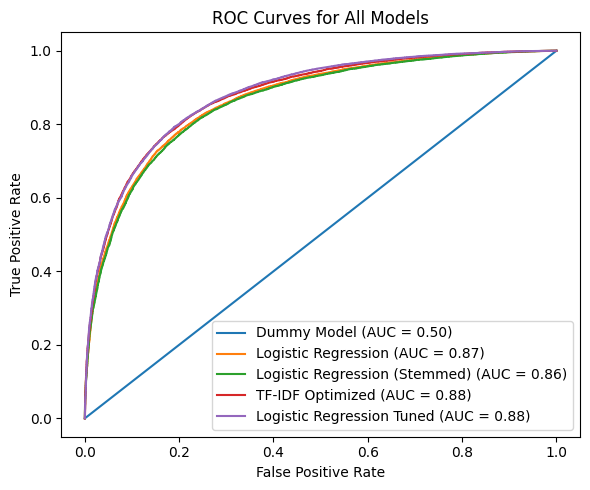

In [18]:
from sklearn.metrics import roc_curve, auc

# Calculate predicted probabilities for each model
y_val_prob_dummy = dummy_model.predict_proba(X_val)[:, 1]
y_val_prob_logistic = logistic_model.predict_proba(X_val)[:, 1]
y_val_prob_logistic2 = logistic_model2.predict_proba(X_val2)[:, 1]
y_val_prob_logistic3 = logistic_model3.predict_proba(X_val2)[:, 1]
y_val_prob_stemmed = logistic_model_stemmed.predict_proba(X_val_stemmed)[:, 1]

# Generate ROC curves
plt.figure(figsize=(6, 5))

# Dummy model
fpr_dummy, tpr_dummy, _ = roc_curve(y_val, y_val_prob_dummy)
auc_dummy = auc(fpr_dummy, tpr_dummy)
plt.plot(fpr_dummy, tpr_dummy, label=f'Dummy Model (AUC = {auc_dummy:.2f})')

# Logistic Regression (Basic)
fpr_logistic, tpr_logistic, _ = roc_curve(y_val, y_val_prob_logistic)
auc_logistic = auc(fpr_logistic, tpr_logistic)
plt.plot(fpr_logistic, tpr_logistic, label=f'Logistic Regression (AUC = {auc_logistic:.2f})')

# Logistic Regression (Stemmed)
fpr_stemmed, tpr_stemmed, _ = roc_curve(y_val, y_val_prob_stemmed)
auc_stemmed = auc(fpr_stemmed, tpr_stemmed)
plt.plot(fpr_stemmed, tpr_stemmed, label=f'Logistic Regression (Stemmed) (AUC = {auc_stemmed:.2f})')

# Logistic Regression (TF-IDF Optimized)
fpr_logistic2, tpr_logistic2, _ = roc_curve(y_val, y_val_prob_logistic2)
auc_logistic2 = auc(fpr_logistic2, tpr_logistic2)
plt.plot(fpr_logistic2, tpr_logistic2, label=f'TF-IDF Optimized (AUC = {auc_logistic2:.2f})')

# Logistic Regression (Hyperparameter Tuned)
fpr_logistic3, tpr_logistic3, _ = roc_curve(y_val, y_val_prob_logistic3)
auc_logistic3 = auc(fpr_logistic3, tpr_logistic3)
plt.plot(fpr_logistic3, tpr_logistic3, label=f'Logistic Regression Tuned (AUC = {auc_logistic3:.2f})')

# Plot settings
# plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plots/roc_curves.png', dpi=300)
plt.show()

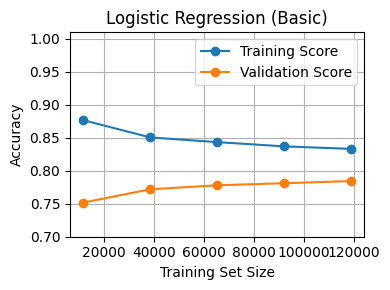

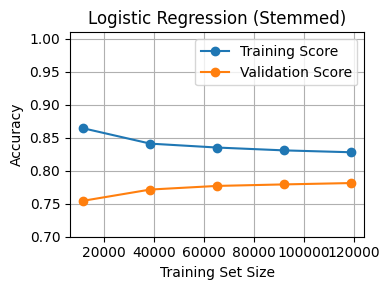

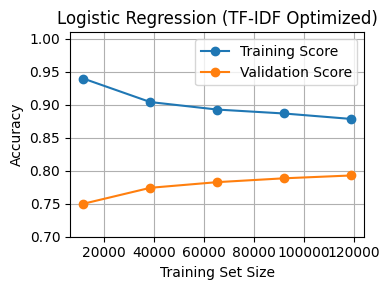

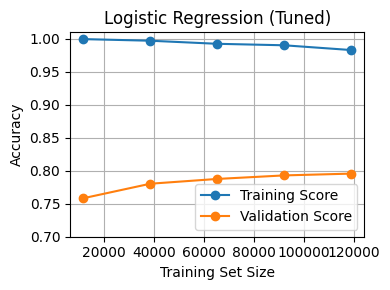

In [19]:
from sklearn.model_selection import learning_curve
import numpy as np

# Function to plot learning curves
def plot_learning_curve(estimator, X, y, title, filename):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
    )
    train_scores_mean = train_scores.mean(axis=1)
    val_scores_mean = val_scores.mean(axis=1)

    plt.figure(figsize=(4, 3))
    plt.plot(train_sizes, train_scores_mean, label='Training Score', marker='o')
    plt.plot(train_sizes, val_scores_mean, label='Validation Score', marker='o')
    plt.title(title)
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')
    plt.ylim([0.7, 1.01])
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

# Plot and save learning curves for all models
plot_learning_curve(logistic_model, X_train, y_train, 'Logistic Regression (Basic)', 'plots/learning_curve_basic.png')
plot_learning_curve(logistic_model_stemmed, X_train_stemmed, y_train, 'Logistic Regression (Stemmed)', 'plots/learning_curve_stemmed.png')
plot_learning_curve(logistic_model2, X_train2, y_train, 'Logistic Regression (TF-IDF Optimized)', 'plots/learning_curve_tfidf_optimized.png')
plot_learning_curve(logistic_model3, X_train2, y_train, 'Logistic Regression (Tuned)', 'plots/learning_curve_tuned.png')


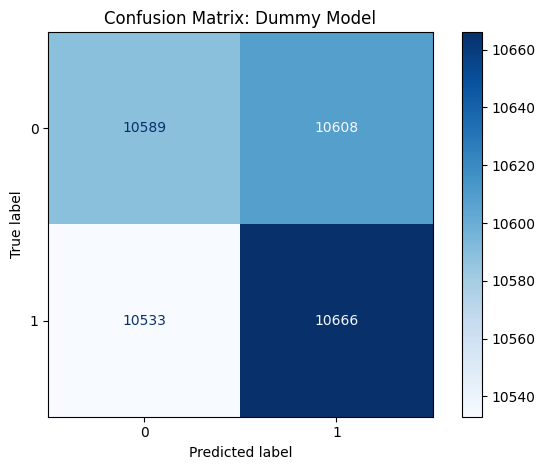

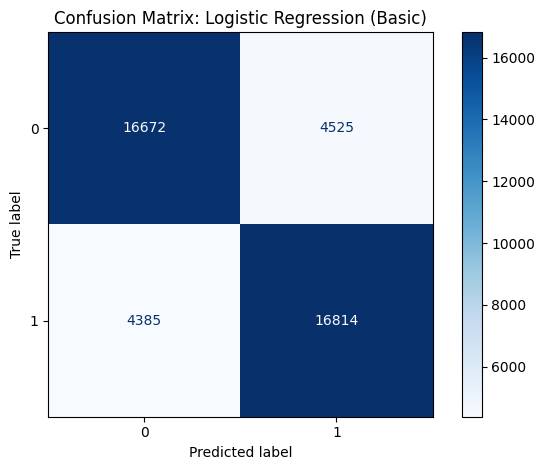

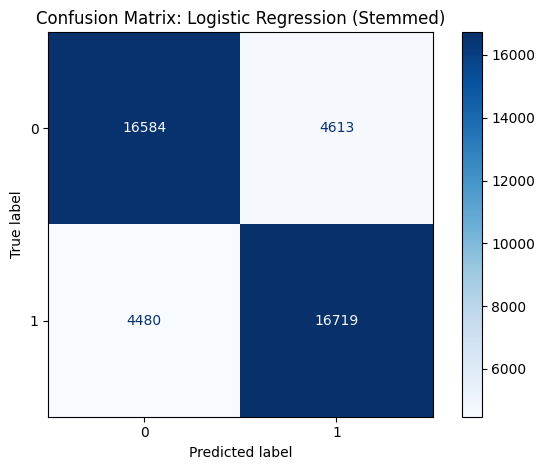

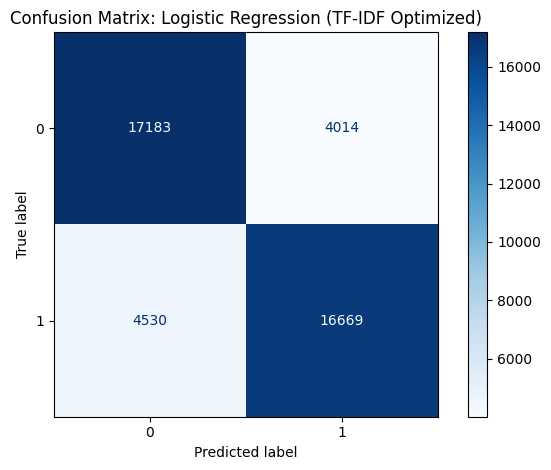

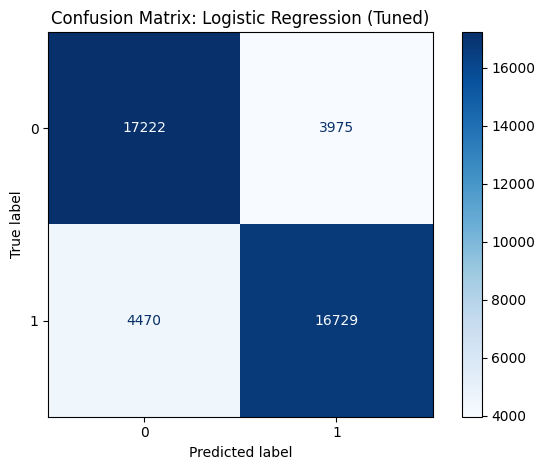

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Function to plot confusion matrix
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

# Plot and save confusion matrices for all models
plot_confusion_matrix(y_val, y_val_pred_dummy, 'Confusion Matrix: Dummy Model', 'plots/confusion_matrix_dummy.png')
plot_confusion_matrix(y_val, y_val_pred_logistic, 'Confusion Matrix: Logistic Regression (Basic)', 'plots/confusion_matrix_logistic_basic.png')
plot_confusion_matrix(y_val, y_val_pred_stemmed, 'Confusion Matrix: Logistic Regression (Stemmed)', 'plots/confusion_matrix_logistic_stemmed.png')
plot_confusion_matrix(y_val, y_val_pred2, 'Confusion Matrix: Logistic Regression (TF-IDF Optimized)', 'plots/confusion_matrix_logistic_tfidf_optimized.png')
plot_confusion_matrix(y_val, y_val_pred3, 'Confusion Matrix: Logistic Regression (Tuned)', 'plots/confusion_matrix_logistic_tuned.png')

In [23]:
X_test = tfidf_vectorizer2.transform(test_data['Clean'])
y_test_pred = logistic_model3.predict(X_test)
test_data['Label'] = y_test_pred
test_data[['ID', 'Label']].to_csv('submission.csv', index=False)